In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [2]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/")

In [3]:
%%capture
!pip install optuna torch plotly botorch

In [4]:
# Import Packages
import os
import pandas as pd
import datetime
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from botorch.acquisition.monte_carlo import qExpectedImprovement
import matplotlib.pyplot as plt
import pickle as pkl

In [5]:
from src.hyperparameter_optimization.botorch_optimization_function import gen_initial_data, get_fitted_model, optimize_acqf_and_get_observation
from src.preprocessing.data_preparation import DataPreparation
from src.preprocessing.feature_scaling import robust_scaling, min_max_scaling
from src.preprocessing.feature_engineering import feature_encoding, create_temporal_features, create_lag_features, expanding_mean_std_weighted_avg
from src.model.base_model.tcn_model import TCNModel
from src.utils.helper_functions import get_approach
from src.utils.evaluate import evaluate_model
from src.utils.train import train
from src.utils.test import test
from src.utils.postprocessing import process_data
from src.utils.metrics import performance_metrics
from src.model.transfer_model.feature_extractor import FeatureExtractor, extract_features
from src.model.transfer_model.transfer_tcn_model import TransferTCNModel
from src.utils.line_plotting import create_line_plot

In [6]:
warnings.filterwarnings("ignore")

# Set seed for numpy
SEED = 1

# # Set seed for PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [7]:
def save_losses(trial_result_file, filepath, iterations, hyperparameters, train_losses, val_losses):
    with open(filepath, 'a') as file:
        file.write(f'Iteration {iterations}, hyperparameters: {hyperparameters}\n')

        for epoch in range(len(train_losses)):
            file.write(f'Epoch {epoch}: train loss = {train_losses[epoch]}, val loss = {val_losses[epoch]}\n')


def objective(parameterization, iter_num, best_iteration, best_loss):

    num_hidden_layers = round(parameterization[:, 0].item())
    num_hidden_size = 2 ** ((round(parameterization[:, 1].item())))
    kernel_size = round(parameterization[:, 2].item())
    dropout = float(parameterization[:, 3].item())
    learning_rate = float(parameterization[:, 4].item())
    batch_size = 2 ** (round(parameterization[:, 5].item()))
    epochs = EPOCHS
    patience = PATIENCE

    train_loader = torch.utils.data.DataLoader(transfer_train_data, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(transfer_val_data, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(transfer_test_data, batch_size=batch_size, shuffle=False)

    # create the model
    model = TransferTCNModel(input_size=transfer_train_features.shape[2], output_size=transfer_y_train.shape[1], num_channels=[num_hidden_size] * num_hidden_layers,
                kernel_size=kernel_size, dropout=dropout).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    # Print hyperparameters for the current iteration
    hyperparameters_str = f"num_hidden_layers = {num_hidden_layers}, num_hidden_size = {num_hidden_size}, " \
                          f"kernel_size = {kernel_size}, dropout = {dropout}, " \
                          f"learning_rate = {learning_rate}, batch_size = {batch_size}"
    # print(f"Iteration: {iter_num}, hyper parameters: {hyperparameters_str}")

    train_loss = []
    val_loss = []
    best_val_loss = float('inf')  # Initialize with a large value
    # Get the current timestamp
    current_time = time.strftime("%Y-%m-%d %H:%M:%S")

    # train the model
    for epoch in range(epochs):
        # training
        model.train()
        epoch_train_loss = []
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs.permute(0, 2, 1))
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_train_loss.append(loss.item())
        avg_train_loss = sum(epoch_train_loss) / len(epoch_train_loss)
        train_loss.append(avg_train_loss)

        # validation

        avg_val_loss = evaluate_model(device = device, model = model, data_loader = val_loader, loss_fn = loss_fn)
        val_loss.append(avg_val_loss)

        # check if validation loss has improved
        if val_loss[-1] < best_val_loss:
            best_val_loss = val_loss[-1]
            counter = 0  # reset counter if validation loss has improved
        else:
            counter += 1  # increment counter if validation loss has not improved

        # check if we should stop training
        if counter >= patience:
            break

        # print progress
        # print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}')

    trial_result_path = os.path.join(transfer_trial_metrics_dir, trial_result_file)

    save_losses(trial_result_file, trial_result_path, iter_num, hyperparameters_str, train_loss, val_loss)

    # Update the best iteration and value if necessary
    if val_loss[-1] < best_loss:
        best_iteration = iter_num
        best_loss = val_loss[-1]

    print()
    print(f"{current_time} - Iteration: {iter_num} finished with value: {avg_val_loss:.4f}: "
      f"num_hidden_layers = '{num_hidden_layers}', "
      f"num_hidden_size = '{num_hidden_size}', "
      f"kernel_size = '{kernel_size}', "
      f"dropout = '{dropout}', "
      f"learning_rate = '{learning_rate}', "
      f"batch_size = '{batch_size}'")

    print(f"Best iteration: {best_iteration} with value: {best_loss:.4f}")

    iter_num += 1

    return torch.tensor(avg_val_loss).view(-1, 1), best_iteration, best_loss

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

Device: cpu



In [9]:
if os.path.exists('/mnt/work/dkale/dkale_Colab/experiments_0.2/'):
    # Define base directory path
    root_dir = '/mnt/work/dkale/dkale_Colab/experiments_0.2/'
else:
    root_dir = '/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/'

current_date = datetime.datetime.now().strftime("%d%m%Y")
approach = get_approach(model_type=1)

In [10]:
used_model = "TCN"
model_version = "1.0"
loss_function_name = "MSE"
optimization_technique = "BO"
github_issue_no = "4.0"

In [11]:
# Define subdirectories
root_data_dir = root_dir + 'data/'
preprocessed_dir = root_data_dir + 'preprocessed/ACN/'
train_val_test_dir = root_data_dir + 'train_val_test/ACN/'
transfer_train_val_test_dir = train_val_test_dir + 'transfer_model'
result_dir = root_dir + 'result/'

# Base Directories
base_result_dir = result_dir + 'base_result/'
base_model_dir = base_result_dir + 'model/'

# Transfer Directories
transfer_train_val_test_dir = train_val_test_dir + 'transfer_model/'
transfer_result_dir = result_dir + 'transfer_result/'
transfer_model_dir = transfer_result_dir + 'model/'
transfer_loss_metrics_dir = transfer_result_dir + 'loss_metrics'
transfer_permormance_metrics_dir = transfer_result_dir + 'performance_metrics'
transfer_trial_metrics_dir = transfer_result_dir + 'trial_metrics'
transfer_test_result_dir = transfer_result_dir + 'test_result'

In [12]:
# Define parameters
HOURS = 24
PAST_DAYS = 7
FUTURE_DAYS = 1
N_PAST = HOURS * PAST_DAYS
N_FUTURE = HOURS * FUTURE_DAYS
EPOCHS = 2
PATIENCE = 3
LAYER_INDEX =2

In [13]:
# BO Parameters
dtype = torch.float
N_INITIAL_DATA = 3  # Getting first set of data by GP
BATCH_SIZE = 3
NUM_RESTARTS = 200    # BoTorch Hyper params
RAW_SAMPLES = 512    # BoTorch Hyper params
ITER_NUM = 0         # Starting iteration No
N_ITERATION = 10      # Total Iteration to complete
BEST_ITERATION = -1  # To track the best Iteration
BEST_LOSS = float('inf')  # To track the best validation loss

bounds = torch.tensor([
    [1, 4, 2, 0.2, 1e-5, 6],  # Lower bounds
    [3, 7, 5, 0.5, 1e-2, 8]  # Upper bounds
], device=device, dtype=dtype)

d  = bounds.shape[1]

study_name = f"Transfer Model, Used Model: {used_model}, Model Version: {model_version}, Loss Function: {loss_function_name}, Optimization Technique: {optimization_technique}, PAST DAYS: {PAST_DAYS} ---> FUTURE DAYS: {FUTURE_DAYS}"
print(f"Study Name: {study_name}\n")

common_file_name = f"{approach}_{used_model}_{model_version}_{loss_function_name}_{optimization_technique}_{github_issue_no}_{PAST_DAYS}.0_{FUTURE_DAYS}.0_{current_date}"

Study Name: Transfer Model, Used Model: TCN, Model Version: 1.0, Loss Function: MSE, Optimization Technique: BO, PAST DAYS: 7 ---> FUTURE DAYS: 1



In [14]:
col_order = ['connectionTime', 'kWhDelivered_Smoothed', 'total_charging_time_Smoothed', 'idle_time_Smoothed', 'siteID_0', 'siteID_1', 'siteID_1_2', 'siteID_2',\
                           'siteID_19', 'Time_of_day_0_4', 'Time_of_day_4_8', 'Time_of_day_8_12', 'Time_of_day_12_16', 'Time_of_day_16_20', 'Time_of_day_20_24', 'Sunday', 'Monday',\
                            'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Weekday', 'Weekend', 'Season', 'Daylight_Saving_Time', 'lag_1', 'lag_2', 'expanding_mean',\
                            'expanding_std', 'weighted_avg', 'Hour_of_Day_sin', 'Hour_of_Day_cos', 'Day_Of_Week_sin', 'Day_Of_Week_cos', 'Day_Of_year_sin', 'Day_Of_year_cos',\
                            'Month_Of_Year_sin', 'Month_Of_Year_cos']

In [15]:
base_model_name = 'TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023.pt'
# define the path to save the model
base_model_path = os.path.join(base_model_dir, base_model_name)

In [16]:
transfer_df = pd.read_csv(rf'{preprocessed_dir}acn_office_0.2_0.1_22_06_2023.csv')

In [17]:
transfer_df = feature_encoding(transfer_df)

In [18]:
transfer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                8500 non-null   datetime64[ns]
 1   kWhDelivered_Smoothed         8500 non-null   float64       
 2   total_charging_time_Smoothed  8500 non-null   float64       
 3   idle_time_Smoothed            8500 non-null   float64       
 4   siteID_0                      8500 non-null   int64         
 5   siteID_19                     8500 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 398.6 KB


In [19]:
transfer_df['siteID_1'] = 0
transfer_df['siteID_1_2'] = 0
transfer_df['siteID_2'] = 0

In [20]:
transfer_df = create_temporal_features(transfer_df)

In [21]:
transfer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                8500 non-null   datetime64[ns]
 1   kWhDelivered_Smoothed         8500 non-null   float64       
 2   total_charging_time_Smoothed  8500 non-null   float64       
 3   idle_time_Smoothed            8500 non-null   float64       
 4   siteID_0                      8500 non-null   int64         
 5   siteID_19                     8500 non-null   int64         
 6   siteID_1                      8500 non-null   int64         
 7   siteID_1_2                    8500 non-null   int64         
 8   siteID_2                      8500 non-null   int64         
 9   Hour_of_Day                   8500 non-null   int64         
 10  Day_Of_Week                   8500 non-null   int64         
 11  Day_Of_year                   

In [22]:
transfer_df["lag_1"] = transfer_df['kWhDelivered_Smoothed'].shift(1)
transfer_df["lag_2"] = transfer_df['kWhDelivered_Smoothed'].shift(2)

In [23]:
transfer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                8500 non-null   datetime64[ns]
 1   kWhDelivered_Smoothed         8500 non-null   float64       
 2   total_charging_time_Smoothed  8500 non-null   float64       
 3   idle_time_Smoothed            8500 non-null   float64       
 4   siteID_0                      8500 non-null   int64         
 5   siteID_19                     8500 non-null   int64         
 6   siteID_1                      8500 non-null   int64         
 7   siteID_1_2                    8500 non-null   int64         
 8   siteID_2                      8500 non-null   int64         
 9   Hour_of_Day                   8500 non-null   int64         
 10  Day_Of_Week                   8500 non-null   int64         
 11  Day_Of_year                   

In [24]:
transfer_df = expanding_mean_std_weighted_avg(dataframe = transfer_df, window_size = 2)

In [25]:
transfer_robust_cols = ['kWhDelivered_Smoothed', 'total_charging_time_Smoothed', 'idle_time_Smoothed', 'lag_1', 'lag_2', 'expanding_mean', 'expanding_std', 'weighted_avg']
transfer_sin_cos_cols = ['Hour_of_Day', 'Day_Of_Week', 'Day_Of_year', 'Month_Of_Year']
transfer_scaled_df, transfer_robust_scaling_params = robust_scaling(df = transfer_df, robust_cols = transfer_robust_cols, sin_cos_cols = transfer_sin_cos_cols)

In [26]:
transfer_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8498 entries, 2 to 8499
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                8498 non-null   datetime64[ns]
 1   kWhDelivered_Smoothed         8498 non-null   float64       
 2   total_charging_time_Smoothed  8498 non-null   float64       
 3   idle_time_Smoothed            8498 non-null   float64       
 4   siteID_0                      8498 non-null   int64         
 5   siteID_19                     8498 non-null   int64         
 6   siteID_1                      8498 non-null   int64         
 7   siteID_1_2                    8498 non-null   int64         
 8   siteID_2                      8498 non-null   int64         
 9   Time_of_day_0_4               8498 non-null   int64         
 10  Time_of_day_4_8               8498 non-null   int64         
 11  Time_of_day_8_12              

In [27]:
transfer_connection_time_list = transfer_scaled_df["connectionTime"].tolist()

In [28]:
second_df_cols = transfer_scaled_df.columns.tolist()
new_cols = [col for col in col_order if col in second_df_cols]
transfer_scaled_df = transfer_scaled_df.loc[:, new_cols]

In [29]:
transfer_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8498 entries, 2 to 8499
Data columns (total 39 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                8498 non-null   datetime64[ns]
 1   kWhDelivered_Smoothed         8498 non-null   float64       
 2   total_charging_time_Smoothed  8498 non-null   float64       
 3   idle_time_Smoothed            8498 non-null   float64       
 4   siteID_0                      8498 non-null   int64         
 5   siteID_1                      8498 non-null   int64         
 6   siteID_1_2                    8498 non-null   int64         
 7   siteID_2                      8498 non-null   int64         
 8   siteID_19                     8498 non-null   int64         
 9   Time_of_day_0_4               8498 non-null   int64         
 10  Time_of_day_4_8               8498 non-null   int64         
 11  Time_of_day_8_12              

In [30]:
# Convert number of days to number of hours
transfer_test_size = 45 * HOURS  #45 days
transfer_val_size = 2232 # 30% of the remaining data (93 days) ---> Train size (216 days)

# Calculate the index to split the data
transfer_train_index = len(transfer_scaled_df) - transfer_test_size - transfer_val_size
transfer_val_index = transfer_train_index + transfer_val_size

# Split the data into training, validation, and testing sets
transfer_train_df = transfer_scaled_df.iloc[:transfer_train_index]
transfer_val_df = transfer_scaled_df.iloc[transfer_train_index:transfer_val_index]
transfer_test_df = transfer_scaled_df.iloc[transfer_val_index:]

In [31]:
# Write the dataframes to separate CSV files
transfer_train_df.to_csv(
        rf'{transfer_train_val_test_dir}acn_office_train_0.2_0.1_22_06_2023.csv',
        index=False)
transfer_val_df.to_csv(
        rf'{transfer_train_val_test_dir}acn_office_val_0.2_0.1_22_06_2023.csv',
        index=False)
transfer_test_df.to_csv(
        rf'{transfer_train_val_test_dir}acn_office_test_0.2_0.1_22_06_2023.csv',
        index=False)

TRANSFER_TRAIN_FILE_NAME = rf'{transfer_train_val_test_dir}acn_office_train_0.2_0.1_22_06_2023.csv'
TRANSFER_VAL_FILE_NAME = rf'{transfer_train_val_test_dir}acn_office_val_0.2_0.1_22_06_2023.csv'
TRANSFER_TEST_FILE_NAME = rf'{transfer_train_val_test_dir}acn_office_test_0.2_0.1_22_06_2023.csv'

In [32]:
dp = DataPreparation(n_future= N_FUTURE, n_past= N_PAST)

In [33]:
transfer_x_train, transfer_y_train = dp.prepare_data(dataframe = transfer_train_df)
transfer_x_val, transfer_y_val = dp.prepare_data(dataframe = transfer_val_df)
transfer_x_test, transfer_y_test = dp.prepare_data(dataframe = transfer_test_df)

In [34]:
transfer_x_train, transfer_y_train = transfer_x_train[:100], transfer_y_train[:100]
transfer_x_val, transfer_y_val = transfer_x_val[:100], transfer_y_val[:100]
transfer_x_test, transfer_y_test = transfer_x_test[:100], transfer_y_test[:100]

In [35]:
transfer_y_train.shape

(100, 24)

In [36]:
base_model = TCNModel(
    input_size=transfer_x_train.shape[2],
    output_size=transfer_y_train.shape[1],
    num_channels=[32] * 4,
    kernel_size=3,
    dropout=0.30131441354751587
).to(device)

# create optimizer and loss function
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=0.0029837472829967737)
base_loss_fn = nn.MSELoss()

In [37]:
feature_extractor = FeatureExtractor(model = base_model, layer_index = LAYER_INDEX)

In [38]:
transfer_train_features = extract_features(torch.from_numpy(transfer_x_train).float().to(device), feature_extractor)
transfer_val_features = extract_features(torch.from_numpy(transfer_x_val).float().to(device), feature_extractor)
transfer_test_features = extract_features(torch.from_numpy(transfer_x_test).float().to(device), feature_extractor)

In [39]:
transfer_y_train = torch.from_numpy(transfer_y_train).float()
transfer_y_val = torch.from_numpy(transfer_y_val).float()
transfer_y_test = torch.from_numpy(transfer_y_test).float()

In [40]:
transfer_train_data = TensorDataset(transfer_train_features, transfer_y_train)
transfer_val_data = TensorDataset(transfer_val_features, transfer_y_val)
transfer_test_data = TensorDataset(transfer_test_features, transfer_y_test)

In [41]:
# call helper function to initialize model
best_observed = []
trial_result_file = f"{common_file_name}_trial_loss_metrics.txt"
print()
print("╔═════════════════════════════════════════════════════════════════════════════╗")
print("║                            Initializing Gaussian Process...                       ║")
print("╚═════════════════════════════════════════════════════════════════════════════╝")
print()
train_x, train_obj, best_value, best_iteration, best_loss = gen_initial_data(n=3, d = d, device = device, bounds = bounds, objective = objective, iteration = ITER_NUM, best_iteration = BEST_ITERATION, best_loss = BEST_LOSS)
best_observed.append(best_value)


╔═════════════════════════════════════════════════════════════════════════════╗
║                            Initializing Gaussian Process...                       ║
╚═════════════════════════════════════════════════════════════════════════════╝


2023-06-23 19:31:37 - Iteration: 0 finished with value: 1.3418: num_hidden_layers = '2', num_hidden_size = '64', kernel_size = '3', dropout = '0.4514012932777405', learning_rate = '0.004257444757968187', batch_size = '128'
Best iteration: 0 with value: 1.3418

2023-06-23 19:31:38 - Iteration: 1 finished with value: 1.4115: num_hidden_layers = '2', num_hidden_size = '16', kernel_size = '4', dropout = '0.47922348976135254', learning_rate = '0.0013890517875552177', batch_size = '128'
Best iteration: 0 with value: 1.3418

2023-06-23 19:31:39 - Iteration: 2 finished with value: 1.3886: num_hidden_layers = '2', num_hidden_size = '128', kernel_size = '5', dropout = '0.4026862382888794', learning_rate = '0.0070565007627010345', batch_size = '256'
Be

In [42]:
train_x_list = []
train_obj_list = []
train_x_list.extend(train_x)
train_obj_list.extend(train_obj)

In [43]:
# Get the current time before starting the BO loop
start_time = time.time()

print("╔═════════════════════════════════════════════════════════════════════════════╗")
print("║                             Running BOTorch:...                                   ║")
print("╚═════════════════════════════════════════════════════════════════════════════╝")
print()
state_dict = None

iteration = N_INITIAL_DATA

# run N_BATCH rounds of BayesOpt after the initial random batch
while iteration <= N_ITERATION:

    train_x = torch.cat(train_x_list, dim=0)
    train_obj = [tensor.to(device) for tensor in train_obj_list]
    train_obj = torch.cat(train_obj, dim=0)

    # fit the model
    model = get_fitted_model(bounds = bounds,
        train_x=train_x,
        train_obj=train_obj,
        state_dict=state_dict,
    )

    best_value = float('inf')  # Initialize with a large value for minimization problem

    for tensor in train_obj_list:
        value = tensor.min().item()
        if value < best_value:
            best_value = value


    # define the qNEI acquisition function
    qEI = qExpectedImprovement(
        model=model, best_f=best_value
    )

    # optimize and get new observation
    new_x, new_obj, current_iteration, best_iteration, best_loss = optimize_acqf_and_get_observation(d = d, device = device, bounds = bounds, \
                                                                                                     objective = objective, acq_func = qEI, \
                                        batch_size = BATCH_SIZE, num_restarts = NUM_RESTARTS, raw_samples = RAW_SAMPLES, iteration_no = iteration, \
                                                                                                     best_iteration = best_iteration, best_loss = best_loss)

    iteration = current_iteration

    # update training points
    train_x_list.extend(new_x)
    train_obj_list.extend(new_obj)

    # update progress
    best_observed.append(best_value)

    state_dict = model.state_dict()

# Get the current time after the BO loop finishes
end_time = time.time()

# Calculate the elapsed time in seconds
elapsed_time = end_time - start_time

# Format the elapsed time
formatted_time = str(datetime.timedelta(seconds=int(elapsed_time)))

print()
print(f"Process completed in {formatted_time}seconds. Exiting program...\n")

╔═════════════════════════════════════════════════════════════════════════════╗
║                             Running BOTorch:...                                   ║
╚═════════════════════════════════════════════════════════════════════════════╝


2023-06-23 19:31:54 - Iteration: 3 finished with value: 1.5537: num_hidden_layers = '2', num_hidden_size = '16', kernel_size = '3', dropout = '0.49590736627578735', learning_rate = '0.0010919980704784393', batch_size = '64'
Best iteration: 0 with value: 1.3418

2023-06-23 19:31:54 - Iteration: 4 finished with value: 1.4484: num_hidden_layers = '2', num_hidden_size = '16', kernel_size = '4', dropout = '0.4865753650665283', learning_rate = '0.00010343569738324732', batch_size = '128'
Best iteration: 0 with value: 1.3418

2023-06-23 19:31:54 - Iteration: 5 finished with value: 1.4241: num_hidden_layers = '2', num_hidden_size = '16', kernel_size = '5', dropout = '0.4581450819969177', learning_rate = '0.002641606843098998', batch_size = '128'
Best

In [44]:
trial_result_file_path = os.path.join(transfer_trial_metrics_dir, trial_result_file)
print(f"File '{trial_result_file}' has been successfully saved: {trial_result_file_path}\n")

File 'TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_trial_loss_metrics.txt' has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/trial_metrics/TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_trial_loss_metrics.txt



In [45]:
# Convert the list of tensors to a single tensor
train_obj_tensor = torch.cat(train_obj_list, dim=0)

# Find the index of the minimum loss
min_loss_idx = train_obj_tensor.argmin().item()

# Get the corresponding best hyperparameters
best_hyperparameters = train_x_list[min_loss_idx].squeeze().tolist()

print("Minimum loss index:", min_loss_idx)
print("Best hyperparameters:", best_hyperparameters)

Minimum loss index: 0
Best hyperparameters: [1.8498923778533936, 6.012883186340332, 3.3775763511657715, 0.4514012932777405, 0.004257444757968187, 7.431514263153076]


In [46]:
best_loss = float(best_loss)
best_num_hidden_layers = round(best_hyperparameters[0])
best_num_hidden_size = 2 ** (round(best_hyperparameters[1]))
best_kernel_size = round(best_hyperparameters[2])
best_dropout = float(best_hyperparameters[3])
best_learning_rate = float(best_hyperparameters[4])
best_batch_size = 2 ** (round(best_hyperparameters[5]))

In [47]:
print(f'  Best trial: {min_loss_idx} with val loss: {best_loss:.4f}')
print(f'  Best number of hidden layers: {best_num_hidden_layers}')
print(f'  Best number of hidden size: {best_num_hidden_size}')
print(f'  Best kernel size: {best_kernel_size}')
print(f'  Best dropout: {best_dropout}')
print(f'  Best learning rate: {best_learning_rate}')
print(f'  Best batch size : {best_batch_size }\n')

  Best trial: 0 with val loss: 1.3418
  Best number of hidden layers: 2
  Best number of hidden size: 64
  Best kernel size: 3
  Best dropout: 0.4514012932777405
  Best learning rate: 0.004257444757968187
  Best batch size : 128



In [48]:
transfer_train_loader = torch.utils.data.DataLoader(transfer_train_data, batch_size=best_batch_size, shuffle=False)
transfer_val_loader = torch.utils.data.DataLoader(transfer_val_data, batch_size=best_batch_size, shuffle=False)
transfer_test_loader = torch.utils.data.DataLoader(transfer_test_data, batch_size=best_batch_size, shuffle=False)

In [49]:
transfer_model = TransferTCNModel(
        input_size=transfer_train_features.shape[2],
        output_size=transfer_y_train.shape[1],
        num_channels=best_num_hidden_layers * [best_num_hidden_size],
        kernel_size=best_kernel_size,
        dropout=best_dropout
    ).to(device)

In [50]:
# create optimizer and loss function
transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=best_learning_rate)
transfer_loss_fn = nn.MSELoss()

In [51]:
# train the model
transfer_train_loss, transfer_val_loss = train(
    device = device,
    model=transfer_model,
    optimizer=transfer_optimizer,
    loss_fn=transfer_loss_fn,
    train_loader=transfer_train_loader,
    val_loader=transfer_val_loader,
    epochs=EPOCHS,
    patience=PATIENCE,
    filename=os.path.join(transfer_loss_metrics_dir, f'{common_file_name}_loss_metrics.pkl'))

Training started........................

Epoch 1/2, Train Loss: 0.3391, Val Loss: 1.4090
Epoch 2/2, Train Loss: 0.3269, Val Loss: 1.3473


Train and validation losses have been saved to: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/loss_metrics/TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_loss_metrics.pkl



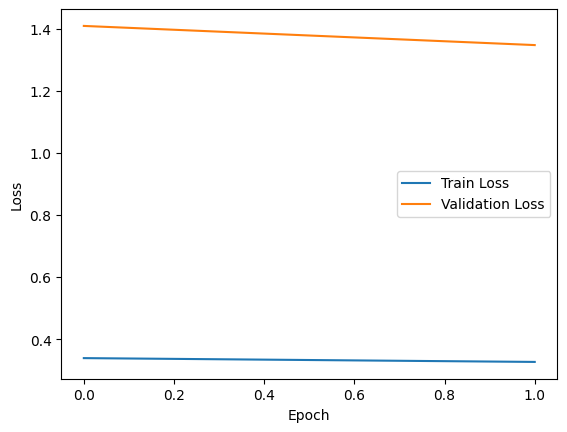

In [52]:
plt.plot(transfer_train_loss, label='Train Loss')
plt.plot(transfer_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [53]:
transfer_model_name = f'{common_file_name}.pt'
# define the path to save the model
transfer_model_path = os.path.join(transfer_model_dir, transfer_model_name)

In [54]:
# save the model to the specified path
if not os.path.exists(os.path.dirname(transfer_model_path)):
    os.makedirs(os.path.dirname(transfer_model_path))
torch.save(transfer_model.state_dict(), transfer_model_path)
print(f'The transfer trained model: {transfer_model_name} has been successfully saved: "{transfer_model_path}".\n')

The transfer trained model: TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023.pt has been successfully saved: "/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/model/TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023.pt".



In [55]:
if os.path.exists(transfer_model_path):
    transfer_model.load_state_dict(torch.load(transfer_model_path))
    transfer_test_loss, transfer_y_pred = test(device = device, model = transfer_model, test_loader = transfer_test_loader, loss_fn = transfer_loss_fn)
else:
    print(f"File not found at path: {transfer_model_path}\n")

Test Loss: 1.9903



In [56]:
transfer_result_df, transfer_result_df_daily = process_data(
    y_test=transfer_y_test,
    y_pred=transfer_y_pred,
    scaling_type = 'robust',
    scaling_params=transfer_robust_scaling_params,
    connection_time_list=transfer_connection_time_list,
    train_df=transfer_train_df,
    val_df=transfer_val_df,
    scaled_df=transfer_scaled_df,
    n_past=N_PAST,
    n_future=N_FUTURE
)

In [57]:
# Save transfer_result_df as pickle
transfer_result_df_file_name = f'{common_file_name}_transfer_result_df.pkl'
transfer_result_df_file_path = os.path.join(transfer_test_result_dir, transfer_result_df_file_name)
transfer_result_df.to_pickle(transfer_result_df_file_path)
print(f"Transfer result DataFrame {transfer_result_df_file_name} has been successfully saved: {transfer_result_df_file_path}.\n")

# Save base_result_df_daily as pickle
transfer_result_df_daily_file_name = f'{common_file_name}_transfer_result_df_daily.pkl'
transfer_result_df_daily_file_path = os.path.join(transfer_test_result_dir, transfer_result_df_daily_file_name)
transfer_result_df_daily.to_pickle(transfer_result_df_daily_file_path)
print(f"Transfer result daily DataFrame {transfer_result_df_daily_file_name} has been successfully saved: {transfer_result_df_daily_file_path}.\n")

Transfer result DataFrame TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_transfer_result_df.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/test_result/TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_transfer_result_df.pkl.

Transfer result daily DataFrame TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_transfer_result_df_daily.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/test_result/TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_transfer_result_df_daily.pkl.



In [58]:
transfer_mae, transfer_r2, transfer_mse, transfer_rms = performance_metrics(result_df = transfer_result_df_daily)

In [59]:
print(f"Transfer MAE: {transfer_mae}")
print(f"Transfer R2 score: {transfer_r2}")
print(f"Transfer MSE: {transfer_mse}")
print(f"Transfer RMS: {transfer_rms}\n")

Transfer MAE: 1.4527180194854736
Transfer R2 score: -1.4218563884644677
Transfer MSE: 3.1180801391601562
Transfer RMS: 1.7658086360532266



In [60]:
performance_metrics_file_name = f'{common_file_name}_performance_metrics.pkl'
performance_metrics_file_path = os.path.join(transfer_permormance_metrics_dir, performance_metrics_file_name)
# save the performance metrics in a separate pickle file
with open(performance_metrics_file_path, 'wb') as f:
    '''Saving the performance matrix'''
    pkl.dump({'transfer test_loss':transfer_test_loss, 'transfer mae': transfer_mae, 'transfer r2': transfer_r2, 'transfer mse': transfer_mse, 'transfer rms': transfer_rms}, f)

print(f"Performance metrics for transfer model: {performance_metrics_file_name} has been successfully saved: {performance_metrics_file_path}.\n")

Performance metrics for transfer model: TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_performance_metrics.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/performance_metrics/TL_TM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023_performance_metrics.pkl.



In [61]:
create_line_plot(transfer_result_df_daily, title = 'Actual vs Predicted kWh Delivered Avg Daily-Transfer TCN Model')